# DepthAnythingv2 Pipeline

In [1]:
import torch
import torch.nn as nn
import cv2
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import open3d as o3d
import sys
sys.path.append("../")
from utils.imageSelector import select_equally_distributed_images

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Loading and viewing images

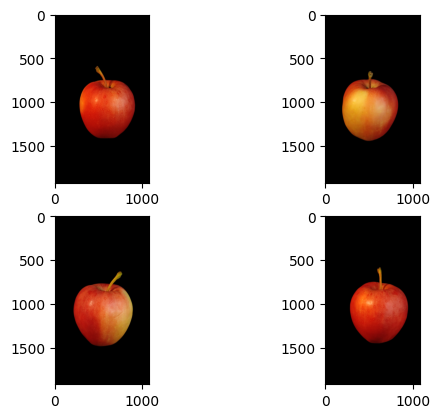

In [64]:
# Import images

input_dir = "../data/images"
image_paths = select_equally_distributed_images(input_dir, n = 5)[0:4]

# Load images and display them

images = [Image.open(path).convert("RGB") for path in image_paths]

f, axarr = plt.subplots(2,2)
axarr[0,0].imshow(images[0])
axarr[0,1].imshow(images[1])
axarr[1,0].imshow(images[2])
axarr[1,1].imshow(images[3])


## Generating the Depth Images

In [65]:
# Loading the model

#model_path = "depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf"
model_path = "depth-anything/Depth-Anything-V2-Small-hf"
processor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModelForDepthEstimation.from_pretrained(model_path).eval()


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

In [66]:
# Generate depth maps

depth_maps = []
for image in images:
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_depth = outputs.predicted_depth.squeeze().cpu().numpy()
    
    # Resize to match input resolution
    predicted_depth_resized = cv2.resize(predicted_depth, (image.width, image.height))
    
    depth_maps.append(predicted_depth_resized)

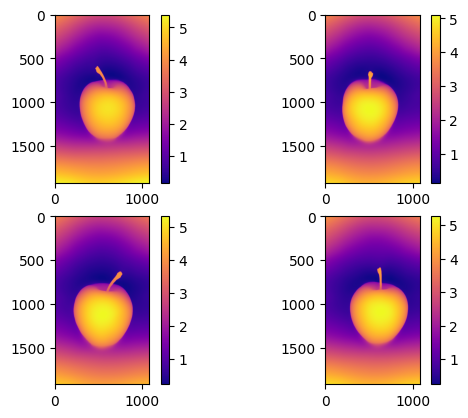

In [67]:
# Visualize the depth maps

f, axarr = plt.subplots(2,2)
im00 = axarr[0,0].imshow(depth_maps[0], cmap='plasma')
im01 = axarr[0,1].imshow(depth_maps[1], cmap='plasma')
im10 = axarr[1,0].imshow(depth_maps[2], cmap='plasma')
im11 = axarr[1,1].imshow(depth_maps[3], cmap='plasma')

f.colorbar(im00, ax=axarr[0,0])
f.colorbar(im01, ax=axarr[0,1])
f.colorbar(im10, ax=axarr[1,0])
f.colorbar(im11, ax=axarr[1,1])


## Convert to point clouds

In [25]:
# Setting camera parameters (Supposition)
fx = 1.73385664e+03  # focal length x (pixels)
fy = 1.76271719e+03  # focal length y (pixels)

In [82]:
# Convert images and depth maps to float32 for further processing

images_float = [np.array(image, dtype=np.float32) / 255.0 for image in images]
depth_float = [depth.astype(np.float32) for depth in depth_maps]

point_clouds = []

for img, depth in zip(images_float, depth_float):
    
    h, w = depth.shape

    # Create meshgrid
    i, j = np.meshgrid(np.arange(w), np.arange(h))
    z = depth
    x = (i - w/2) * z / 470.4 #fx
    y = (j - h/2) * z / 470.4 #fy

    # Flatten
    xyz = np.stack((x, y, z), axis=-1).reshape(-1, 3)
    colors = img.reshape(-1, 3)

    # Remove points with zero depth
    mask = (z > 0).reshape(-1)
    xyz = xyz[mask]
    colors = colors[mask]

    # Keep only non-black (or non-near-black) points
    keep_mask = np.any(colors > 0.5, axis=1)
    filtered_points = xyz[keep_mask]
    filtered_colors = colors[keep_mask]

    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(filtered_points)
    pcd.colors = o3d.utility.Vector3dVector(filtered_colors)

    # Filter distant points
    pcd, ind = o3d.geometry.PointCloud.remove_statistical_outlier(
        pcd,
        nb_neighbors=20,
        std_ratio=2.0
    )
    o3d.visualization.draw_geometries([pcd])
    point_clouds.append(pcd)

## Aligne the point clouds

In [69]:
def robust_align_pca_obb(pc: o3d.geometry.PointCloud) -> o3d.geometry.PointCloud:
    """
    Robust PCA + OBB alignment preserving colors and normals.
    """

    points = np.asarray(pc.points)
    colors = np.asarray(pc.colors) if pc.has_colors() else None
    normals = np.asarray(pc.normals) if pc.has_normals() else None

    # ---------- PCA ALIGNMENT ----------
    centroid = points.mean(axis=0)
    centered = points - centroid

    cov = centered.T @ centered / centered.shape[0]

    eigvals, eigvecs = np.linalg.eigh(cov)

    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]

    if np.linalg.det(eigvecs) < 0:
        eigvecs[:, 2] *= -1

    pca_points = centered @ eigvecs

    # Rotate normals if they exist
    if normals is not None:
        normals = normals @ eigvecs

    # ---------- OBB REFINEMENT ----------
    pca_pc = o3d.geometry.PointCloud()
    pca_pc.points = o3d.utility.Vector3dVector(pca_points)

    obb = pca_pc.get_oriented_bounding_box()

    R = obb.R
    obb_center = obb.center

    refined_points = (pca_points - obb_center) @ R

    if normals is not None:
        normals = normals @ R

    # ---------- CONSISTENT AXIS ORIENTATION ----------
    extents = refined_points.max(axis=0) - refined_points.min(axis=0)

    order = np.argsort(extents)[::-1]

    refined_points = refined_points[:, order]

    if normals is not None:
        normals = normals[:, order]

    # enforce consistent direction
    if refined_points[:, 0].mean() < 0:
        refined_points[:, 0] *= -1
        if normals is not None:
            normals[:, 0] *= -1

    if refined_points[:, 1].mean() < 0:
        refined_points[:, 1] *= -1
        if normals is not None:
            normals[:, 1] *= -1

    # ---------- BUILD OUTPUT CLOUD ----------
    aligned_pc = o3d.geometry.PointCloud()

    aligned_pc.points = o3d.utility.Vector3dVector(refined_points)

    if colors is not None:
        aligned_pc.colors = o3d.utility.Vector3dVector(colors)

    if normals is not None:
        aligned_pc.normals = o3d.utility.Vector3dVector(normals)

    return aligned_pc

In [83]:
# PCA alignment of the point clouds
aligned_point_clouds = []
for pcd in point_clouds:
    pcd = robust_align_pca_obb(pcd)
    aligned_point_clouds.append(pcd)

In [84]:
# Draw a plane 
bbox = pcd.get_axis_aligned_bounding_box()
min_bound = bbox.get_min_bound()
max_bound = bbox.get_max_bound()
plane_size=2.0

# XY is red, XZ is green, YZ is blue
plane1 = o3d.geometry.TriangleMesh.create_box(width=plane_size, height=plane_size, depth=0.001)
plane1.translate([min_bound[0], min_bound[1], min_bound[2]])
plane1.paint_uniform_color([1, 0, 0])  # Red

plane2 = o3d.geometry.TriangleMesh.create_box(width=plane_size, height=0.001, depth=plane_size)
plane2.translate([min_bound[0], min_bound[1], min_bound[2]])
plane2.paint_uniform_color([0, 1, 0])  # Green

plane3 = o3d.geometry.TriangleMesh.create_box(width=0.001, height=plane_size, depth=plane_size)
plane3.translate([min_bound[0], min_bound[1], min_bound[2]])
plane3.paint_uniform_color([0, 0, 1])  # Blue

# Visualize the aligned point clouds together
o3d.visualization.draw_geometries(aligned_point_clouds + [plane1 + plane2 + plane3])

## Rotate the Point clouds

In [85]:
# Rotate the second cloud by 90 degrees around the X-axis
R = pcd.get_rotation_matrix_from_axis_angle([np.pi/2, 0, 0])
aligned_point_clouds[1].rotate(R, center=(0, 0, 0))

# Rotate the third cloud by 180 degrees around the X-axis
R = pcd.get_rotation_matrix_from_axis_angle([np.pi, 0, 0])
aligned_point_clouds[2].rotate(R, center=(0, 0, 0))

# Rotate the forth cloud by 270 degrees around the X-axis
R = pcd.get_rotation_matrix_from_axis_angle([np.pi*3/2, 0, 0])
aligned_point_clouds[3].rotate(R, center=(0, 0, 0))

o3d.visualization.draw_geometries(aligned_point_clouds)